In [1]:
import pandas as pd
 
white_wine = pd.read_csv("data/winequality-white.csv", sep=";")
red_wine = pd.read_csv("data/winequality-red.csv", sep=",")

In [2]:
import mlflow
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("wine_quality_experiment")

C:\Users\sujit\miniconda3\envs\mlflow_lab2_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026/04/23 20:04:44 INFO mlflow.tracking.fluent: Experiment with name 'wine_quality_experiment' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///C:/ML Ops/Labs/lab6/mlruns/1', creation_time=1776989084181, experiment_id='1', last_update_time=1776989084181, lifecycle_stage='active', name='wine_quality_experiment', tags={}, trace_location=None, workspace='default'>

In [3]:
white_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [4]:
red_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
red_wine['is_red'] = 1
white_wine['is_red'] = 0
 
data = pd.concat([red_wine, white_wine], axis=0)
 
# Remove spaces from column names
data.rename(columns=lambda x: x.replace(' ', '_'), inplace=True)

In [6]:
data.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,is_red
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1


C:\Users\sujit\AppData\Local\Temp\ipykernel_35668\1772149765.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data.quality, kde=False);


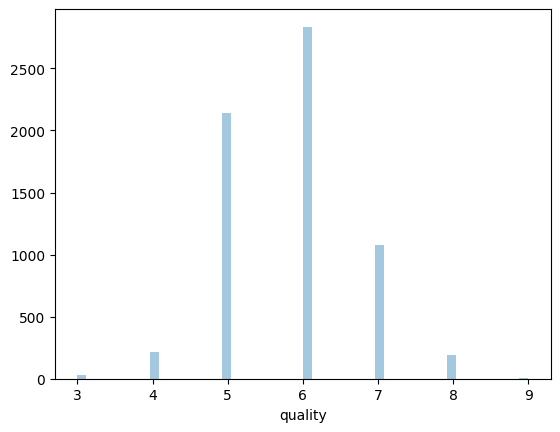

In [7]:
import seaborn as sns
sns.distplot(data.quality, kde=False);

Looks like quality scores are normally distributed between 3 and 9.

Define a wine as high quality if it has quality >= 7.

In [8]:
high_quality = (data.quality >= 7).astype(int)
data.quality = high_quality

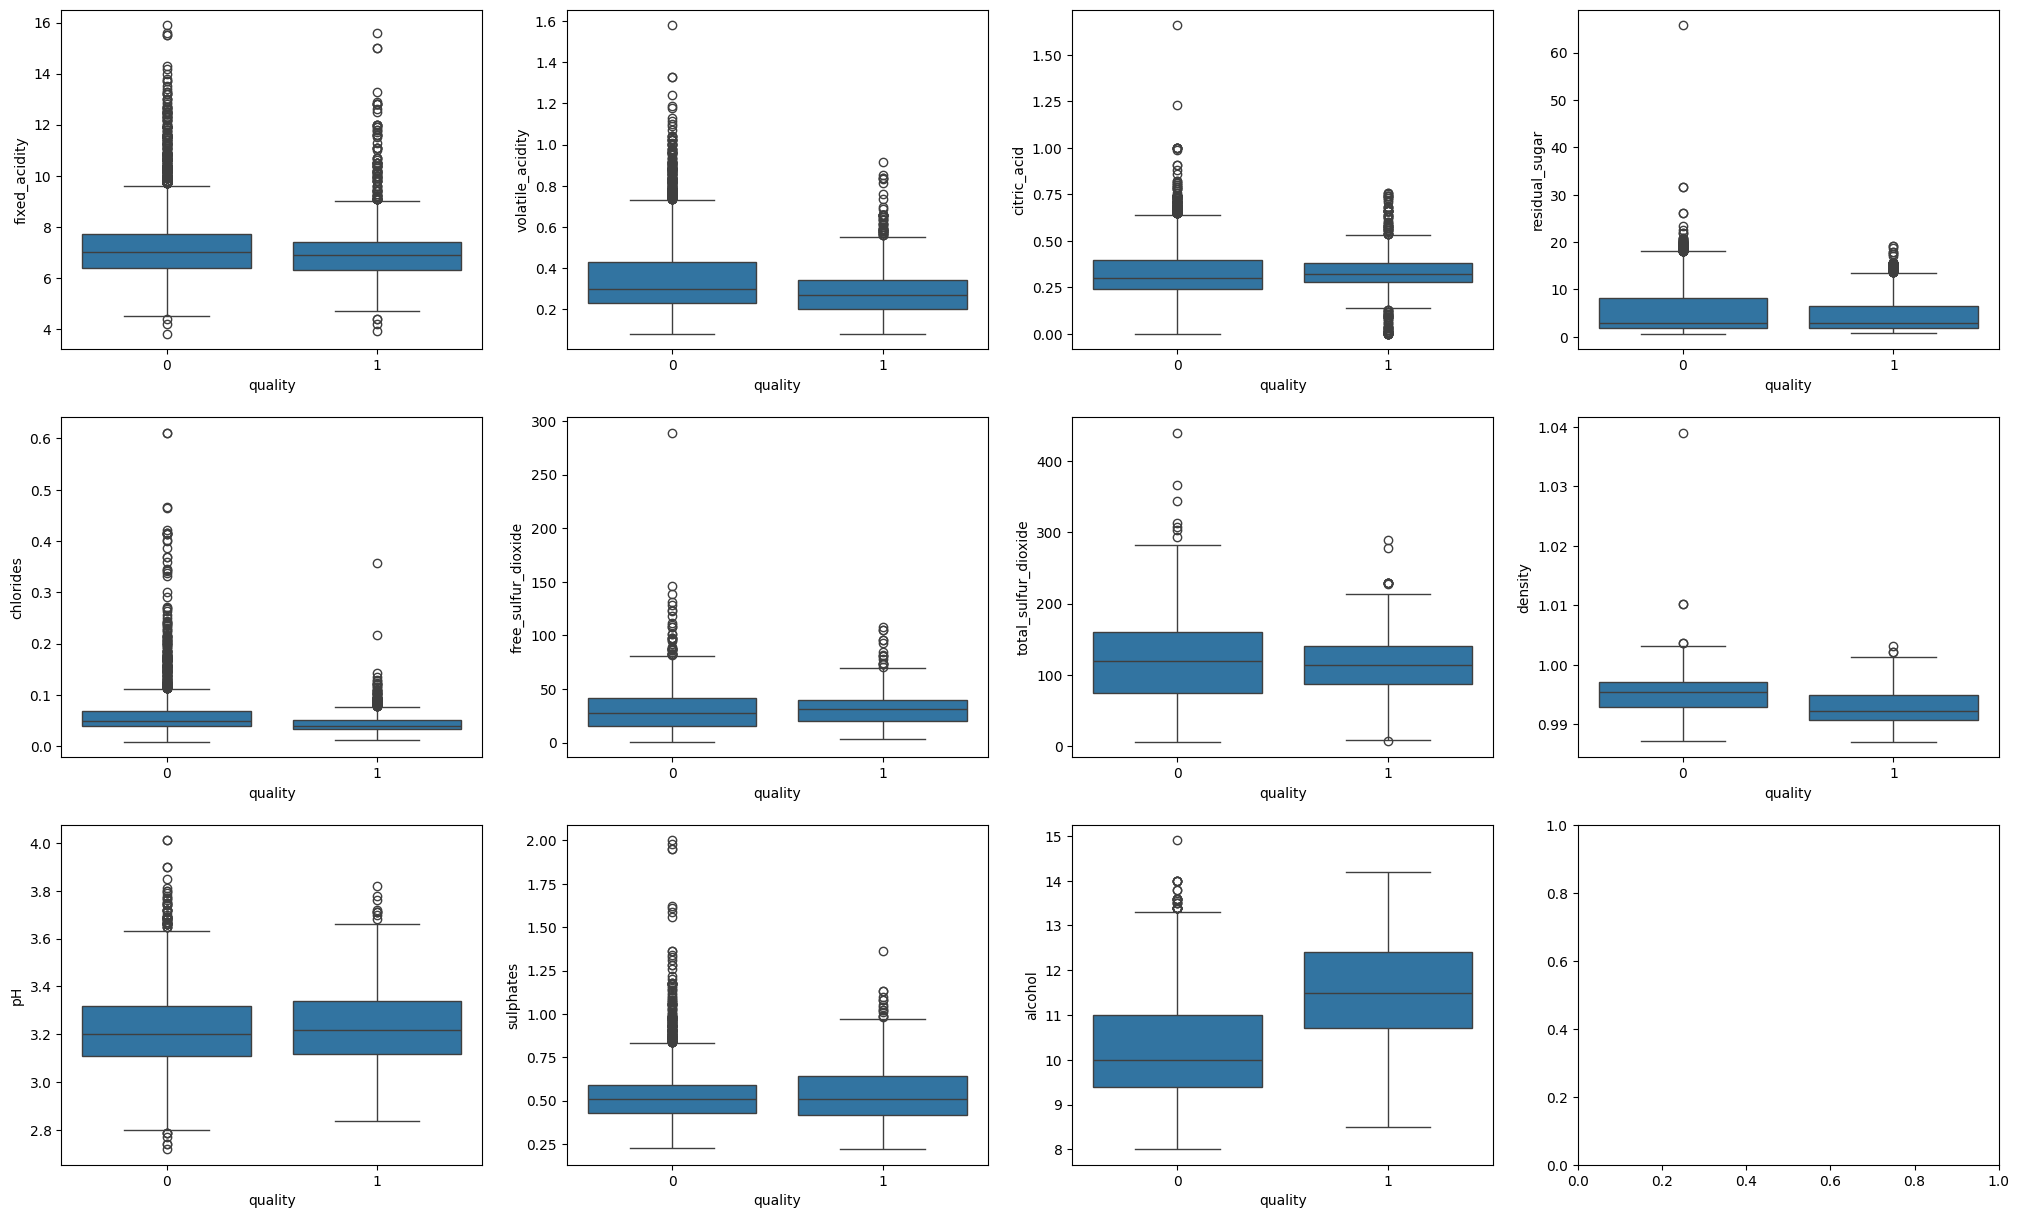

In [9]:
import matplotlib.pyplot as plt
 
dims = (3, 4)
 
f, axes = plt.subplots(dims[0], dims[1], figsize=(25, 15))
axis_i, axis_j = 0, 0
for col in data.columns:
  if col == 'is_red' or col == 'quality':
    continue # Box plots cannot be used on indicator variables
  sns.boxplot(x=high_quality, y=data[col], ax=axes[axis_i, axis_j])
  axis_j += 1
  if axis_j == dims[1]:
    axis_i += 1
    axis_j = 0

In the above box plots, a few variables stand out as good univariate predictors of quality.

In the alcohol box plot, the median alcohol content of high quality wines is greater than even the 75th quantile of low quality wines. High alcohol content is correlated with quality.
In the density box plot, low quality wines have a greater density than high quality wines. Density is inversely correlated with quality.

In [10]:
data.isna().any()


fixed_acidity           False
volatile_acidity        False
citric_acid             False
residual_sugar          False
chlorides               False
free_sulfur_dioxide     False
total_sulfur_dioxide    False
density                 False
pH                      False
sulphates               False
alcohol                 False
quality                 False
is_red                  False
dtype: bool

In [11]:
from sklearn.model_selection import train_test_split
 
X = data.drop(["quality"], axis=1)
y = data.quality
 
# Split out the training data
X_train, X_rem, y_train, y_rem = train_test_split(X, y, train_size=0.6, random_state=123)
 
# Split the remaining data equally into validation and test
X_val, X_test, y_val, y_test = train_test_split(X_rem, y_rem, test_size=0.5, random_state=123)

### Build a baseline model

This task seems well suited to a random forest classifier, since the output is binary and there may be interactions between multiple variables.

The following code builds a simple classifier using scikit-learn. It uses MLflow to keep track of the model accuracy, and to save the model for later use.

In [16]:
import mlflow
import mlflow.pyfunc
import mlflow.sklearn
import numpy as np
import sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from mlflow.models.signature import infer_signature
from mlflow.utils.environment import _mlflow_conda_env
import cloudpickle
import time
 
# The predict method of sklearn's RandomForestClassifier returns a binary classification (0 or 1). 
# The following code creates a wrapper function, SklearnModelWrapper, that uses 
# the predict_proba method to return the probability that the observation belongs to each class. 
 
class SklearnModelWrapper(mlflow.pyfunc.PythonModel):
  def __init__(self, model):
    self.model = model
    
  def predict(self, context, model_input):
    return self.model.predict_proba(model_input)[:,1]


# mlflow.start_run creates a new MLflow run to track the performance of this model. 
# Within the context, you call mlflow.log_param to keep track of the parameters used, and
# mlflow.log_metric to record metrics like accuracy.
with mlflow.start_run(run_name='untuned_random_forest'):
    n_estimators = 10
    model = RandomForestClassifier(n_estimators=n_estimators, random_state=np.random.RandomState(123))
    model.fit(X_train, y_train)

    # predict_proba returns [prob_negative, prob_positive], so slice the output with [:, 1]
    predictions_test = model.predict_proba(X_test)[:,1]
    auc_score = roc_auc_score(y_test, predictions_test)
    mlflow.log_param('n_estimators', n_estimators)
    # Use the area under the ROC curve as a metric.
    mlflow.log_metric('auc', auc_score)
    wrappedModel = SklearnModelWrapper(model)
    # Log the model with a signature that defines the schema of the model's inputs and outputs. 
    # When the model is deployed, this signature will be used to validate inputs.
    signature = infer_signature(X_train, wrappedModel.predict(None, X_train))
    
    # MLflow contains utilities to create a conda environment used to serve models.
    # The necessary dependencies are added to a conda.yaml file which is logged along with the model.
    conda_env =  _mlflow_conda_env(
            additional_conda_deps=None,
            additional_pip_deps=["cloudpickle=={}".format(cloudpickle.__version__), "scikit-learn=={}".format(sklearn.__version__)],
            additional_conda_channels=None,
        )
    model_info = mlflow.pyfunc.log_model(
        name="random_forest_model",
        python_model=wrappedModel,
        conda_env=conda_env,
        signature=signature,
    )

    from sklearn.metrics import (
        accuracy_score, f1_score, precision_score,
        recall_score, log_loss
    )

    preds_proba = model.predict_proba(X_test)[:, 1]
    preds_class = (preds_proba >= 0.5).astype(int)

    mlflow.log_metric("accuracy", accuracy_score(y_test, preds_class))
    mlflow.log_metric("f1", f1_score(y_test, preds_class))
    mlflow.log_metric("precision", precision_score(y_test, preds_class))
    mlflow.log_metric("recall", recall_score(y_test, preds_class))
    mlflow.log_metric("log_loss", log_loss(y_test, preds_proba))

C:\Users\sujit\miniconda3\envs\mlflow_lab2_env\Lib\site-packages\mlflow\pyfunc\utils\data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
C:\Users\sujit\miniconda3\envs\mlflow_lab2_env\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Intege

In [17]:
print("y_test unique values:", y_test.unique())
print("y_test dtype:", y_test.dtype)
print("y_test sample:", y_test.head().tolist())

y_test unique values: [0 1]
y_test dtype: int64
y_test sample: [0, 0, 0, 0, 0]


In [18]:
feature_importances = pd.DataFrame(model.feature_importances_, index=X_train.columns.tolist(), columns=['importance'])
feature_importances.sort_values('importance', ascending=False)

,importance
alcohol,0.160192
density,0.117415
volatile_acidity,0.093136
chlorides,0.086618
residual_sugar,0.082544
free_sulfur_dioxide,0.080473
pH,0.080212
total_sulfur_dioxide,0.077798
sulphates,0.075780
citric_acid,0.071857


As illustrated by the boxplots shown previously, both alcohol and density are important in predicting quality.

You logged the Area Under the ROC Curve (AUC) to MLflow. Click Experiment at the upper right to display the Experiment Runs sidebar.

The model achieved an AUC of 0.854.

A random classifier would have an AUC of 0.5, and higher AUC values are better. For more information, see Receiver Operating Characteristic Curve.

Register the model in MLflow Model Registry
By registering this model in Model Registry, you can easily reference the model from anywhere within Databricks.

The following section shows how to do this programmatically, but you can also register a model using the UI. See "Create or register a model using the UI" (AWS|Azure|GCP).

In [19]:
run_id = mlflow.search_runs(filter_string='tags.mlflow.runName = "untuned_random_forest"').iloc[0].run_id

In [20]:
run_id

'4c6a13880c4e41cb922721e9585ca4ae'

In [21]:
# If you see the error "PERMISSION_DENIED: User does not have any permission level assigned to the registered model", 
# the cause may be that a model already exists with the name "wine_quality". Try using a different name.
model_name = "wine_quality"
model_version = mlflow.register_model(f"runs:/{run_id}/random_forest_model", model_name)
 
# Registering the model takes a few seconds, so add a small delay
time.sleep(15)

Successfully registered model 'wine_quality'.
2026/04/23 20:14:33 WARNING mlflow.tracking._model_registry.fluent: Run with id 4c6a13880c4e41cb922721e9585ca4ae has no artifacts at artifact path 'random_forest_model', registering model based on models:/m-4d28c6d027bb441db4ff8f50a9767637 instead
Created version '1' of model 'wine_quality'.


In [22]:
"""
The MlflowClient class allows you to interact with the MLflow Tracking Server programmatically. 
You can use it to perform various tasks, such as creating and managing experiments, starting 
and managing runs, logging metrics and parameters, and querying information about experiments and runs.

"""
from mlflow.tracking import MlflowClient
client = MlflowClient()

# MLflow 3 removed stage transitions. Modern replacement: aliases.
# @champion marks the current production-serving version;
# @challenger tracks a candidate for promotion.
client.set_registered_model_alias(
    name=model_name,
    alias="champion",
    version=model_version.version,
)
client.set_model_version_tag(
    name=model_name,
    version=model_version.version,
    key="model_type",
    value="random_forest_baseline",
)

The Models page now shows the model version in stage "Production".

You can now refer to the model using the path "models:/wine_quality/production".

In [23]:
# Alias-based URI replaces the old stage-based path
model = mlflow.pyfunc.load_model(f"models:/{model_name}@champion")
 
# Sanity-check: This should match the AUC logged by MLflow
print(f'AUC: {roc_auc_score(y_test, model.predict(X_test))}')
AUC: 0.8540300975814177

AUC: 0.8540300975814177


In [27]:
!pip install "setuptools<81"

   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ---------------------------------------- 1.1/1.1 MB 17.1 MB/s  0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 82.0.1
    Uninstalling setuptools-82.0.1:
      Successfully uninstalled setuptools-82.0.1


## Experiment with a new model

The random forest model performed well even without hyperparameter tuning.

The following code uses the xgboost library to train a more accurate model. It runs a parallel hyperparameter sweep to train multiple models in parallel, using Hyperopt and SparkTrials. As before, the code tracks the performance of each parameter configuration with MLflow.

In [32]:
# hyperopt library imports for defining and executing hyperparameter optimization
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK  
# scope is used for casting hyperopt variables to int when needed (like max_depth)
from hyperopt.pyll import scope  
# math.exp is a mathematical function for calculating exponential values
from math import exp  
# mlflow.xgboost is used to log XGBoost model parameters, metrics, and models with MLflow
import mlflow.xgboost  
import numpy as np  
# xgboost is an implementation of gradient boosted decision trees designed for speed and performance
import xgboost as xgb  

# search_space dictionary defines the range and distribution of hyperparameters for the model
search_space = {
  'max_depth': scope.int(hp.quniform('max_depth', 4, 100, 1)),  # Integer range for tree depth
  'learning_rate': hp.loguniform('learning_rate', -3, 0),  # Log-uniform distribution for learning rate
  'reg_alpha': hp.loguniform('reg_alpha', -5, -1),  # Log-uniform for L1 regularization term
  'reg_lambda': hp.loguniform('reg_lambda', -6, -1),  # Log-uniform for L2 regularization term
  'min_child_weight': hp.loguniform('min_child_weight', -1, 3),  # Log-uniform for minimum sum of instance weight(hessian) needed in a child
  'objective': 'binary:logistic',  # Objective function for binary classification
  'seed': 123,  # Set a seed for deterministic training
}



Nested Runs: When you use mlflow.start_run(nested=True) within the main run, you create nested runs. These runs are associated with the main run and inherit some of its parameters and context. Nested runs are typically used to explore variations or sub-experiments within the main experiment.

python
Copy code
import mlflow

with mlflow.start_run():
    # Your main experiment code goes here

    with mlflow.start_run(nested=True):
        # Nested experiment code goes here
Parameters and metrics logged in the nested run are associated with that specific run and can be accessed separately from the main run.
You can create multiple nested runs within a main run to represent different variations or configurations of your experiment.
python
Copy code
import mlflow

with mlflow.start_run():
    # Your main experiment code goes here

    with mlflow.start_run(nested=True):
        # Nested experiment code 1 goes here

    with mlflow.start_run(nested=True):
        # Nested experiment code 2 goes here

In [33]:
def train_model(params):
      # With MLflow autologging, hyperparameters and the trained model are automatically logged to MLflow.
    mlflow.xgboost.autolog()
    with mlflow.start_run(nested=True):
        train = xgb.DMatrix(data=X_train, label=y_train)
        validation = xgb.DMatrix(data=X_val, label=y_val)
        # Pass in the validation set so xgb can track an evaluation metric. XGBoost terminates training when the evaluation metric
        # is no longer improving.
        booster = xgb.train(params=params, dtrain=train, num_boost_round=1000,\
                            evals=[(validation, "validation")], early_stopping_rounds=50)
        validation_predictions = booster.predict(validation)
        auc_score = roc_auc_score(y_val, validation_predictions)
        mlflow.log_metric('auc', auc_score)

        signature = infer_signature(X_train, booster.predict(train))
        mlflow.xgboost.log_model(booster, "model", signature=signature)

        # Set the loss to -1*auc_score so fmin maximizes the auc_score
        return {'status': STATUS_OK, 'loss': -1*auc_score, 'booster': booster.attributes()}


In [34]:
# !python3 -m pip install pyspark

In [31]:
# # Importing pyspark, the Python API for Spark which lets you write Spark applications using Python
# import pyspark  
# # Importing specific Spark classes to manage configurations and the Spark context
# from pyspark import SparkContext, SparkConf  

# # Setting up the configuration for Spark:
# conf_spark = SparkConf().set("spark.driver.host", "127.0.0.1")  # Configures the Spark driver host address to localhost

# # Creating a SparkContext using the above configuration, essential for connecting to a Spark cluster:
# sc = SparkContext(conf=conf_spark)  # Initializes the main entry point for Spark functionality


KeyboardInterrupt: 

In [22]:
# import pyspark

TPE stands for Tree-structured Parzen Estimator. It's a Bayesian optimization technique that models the probability distribution of the hyperparameters given the observed metrics. It is particularly effective for high-dimensional spaces and has become a popular choice in machine learning for hyperparameter tuning.


In [ ]:
# Sequential trials instead of SparkTrials — Spark doesn't boot cleanly
trials = Trials()

with mlflow.start_run(run_name='xgboost_models'):
    best_params = fmin(
        fn=train_model,
        space=search_space,
        algo=tpe.suggest,
        max_evals=96,
        trials=trials,
    )

  0%|                                                                                                       | 0/96 [00:00<?, ?trial/s, best loss=?]

2026/04/23 20:30:44 WARNING mlflow.utils.autologging_utils: MLflow xgboost autologging is known to be compatible with 2.1.0 <= xgboost, but the installed version is 1.7.6. If you encounter errors during autologging, try upgrading / downgrading xgboost to a compatible version, or try upgrading MLflow.



[0]	validation-logloss:0.55483                                                                                                                     
[1]	validation-logloss:0.47622                                                                                                                     
[2]	validation-logloss:0.43335                                                                                                                     
[3]	validation-logloss:0.39828                                                                                                                     
[4]	validation-logloss:0.37973                                                                                                                     
[5]	validation-logloss:0.36287                                                                                                                     
[6]	validation-logloss:0.35034                                                                                  

2026/04/23 20:30:44 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\sujit\miniconda3\envs\mlflow_lab2_env\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."

2026/04/23 20:30:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.

C:\Users\sujit\miniconda3\e

  1%|▊                                                                           | 1/96 [00:13<21:26, 13.55s/trial, best loss: -0.8899224149874541]

...

2026/04/23 20:31:32 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\sujit\miniconda3\envs\mlflow_lab2_env\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."

2026/04/23 20:31:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.

C:\Users\sujit\miniconda3\e

  4%|███▏                                                                        | 4/96 [01:01<23:30, 15.33s/trial, best loss: -0.8910654084758547]

2026/04/23 20:31:45 WARNING mlflow.utils.autologging_utils: MLflow xgboost autologging is known to be compatible with 2.1.0 <= xgboost, but the installed version is 1.7.6. If you encounter errors during autologging, try upgrading / downgrading xgboost to a compatible version, or try upgrading MLflow.



[0]	validation-logloss:0.54876                                                                                                                     
[1]	validation-logloss:0.46327                                                                                                                     
[2]	validation-logloss:0.40769                                                                                                                     
[3]	validation-logloss:0.37265                                                                                                                     
[4]	validation-logloss:0.35120                                                                                                                     
[5]	validation-logloss:0.33824                                                                                                                     
[6]	validation-logloss:0.32844                                                                                  

2026/04/23 20:31:46 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\sujit\miniconda3\envs\mlflow_lab2_env\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."

2026/04/23 20:31:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



In [ ]:
best_run = mlflow.search_runs(order_by=['metrics.auc DESC']).iloc[0]
print(f'AUC of Best Run: {best_run["metrics.auc"]}')

## Update the production wine_quality model in MLflow Model Registry

Earlier, you saved the baseline model to Model Registry with the name wine_quality. Now that you have a created a more accurate model, update wine_quality.



In [ ]:
new_model_version = mlflow.register_model(f"runs:/{best_run.run_id}/model", model_name)
 
# Registering the model takes a few seconds, so add a small delay
time.sleep(10)

Click Models in the left sidebar to see that the wine_quality model now has two versions.

The following code promotes the new version to production.

In [ ]:
# Reassign @champion to the new XGBoost version (implicitly demotes RF v1).
client.set_registered_model_alias(
    name=model_name,
    alias="champion",
    version=new_model_version.version,
)

# Tag versions for lineage
client.set_model_version_tag(
    name=model_name, version=new_model_version.version,
    key="model_type", value="xgboost_tuned",
)
client.set_model_version_tag(
    name=model_name, version=model_version.version,
    key="status", value="archived",
)

# Keep the old version available as @challenger for rollback/comparison
client.set_registered_model_alias(
    name=model_name,
    alias="challenger",
    version=model_version.version,
)

Clients that call load_model now receive the new model.



In [ ]:
model_uri = f"models:/{model_name}@champion"
model = mlflow.pyfunc.load_model(model_uri)
print(f"AUC: {roc_auc_score(y_test, model.predict(X_test))}")

# Full evaluation suite on the promoted champion model
eval_data = X_test.copy()
eval_data["label"] = y_test
with mlflow.start_run(run_name="champion_evaluation"):
    mlflow.evaluate(
        model=model_uri,
        data=eval_data,
        targets="label",
        model_type="classifier",
        evaluators=["default"],
    )

## Batch inference

There are many scenarios where you might want to evaluate a model on a corpus of new data. For example, you may have a fresh batch of data, or may need to compare the performance of two models on the same corpus of data.

The following code evaluates the model on data stored in a Delta table, using Spark to run the computation in parallel.

In [ ]:
mlflow.pyfunc.spark_udf?


In [ ]:
import mlflow.pyfunc

from pyspark.sql import SparkSession

# Create or retrieve a Spark session
spark = SparkSession.builder \
    .appName("MLflow Integration") \
    .config("spark.some.config.option", "config-value") \
    .getOrCreate()

apply_model_udf = mlflow.pyfunc.spark_udf(spark, f"models:/{model_name}/production")

In [ ]:
# new_data = spark.read.format("csv").load(table_path) # table_path is path to the delta table

In [ ]:
new_model_version

In [ ]:
new_model_version.run_id

In [ ]:
# Serve the model using the MLflow Model Serving

# Run the following in terminal outiside jupyter and after activating the virtual environment
# mlflow models serve --env-manager=local -m models:/wine_quality/production -h 0.0.0.0 -p 5001

- Here **model_name** is `wine_quality`

In [ ]:
import requests
import json

url = 'http://localhost:5001/invocations'

datads_dict = {"dataframe_split": X_test.to_dict(orient='split')}

response = requests.post(url, json=datads_dict)
predictions = response.json()

print(predictions)

In [ ]:
!mlflow ui